In [1]:
import os
import pandas as pd
import numpy as np

path = r'C:\Mon disque D\Gipsa\6- Schizophrenia diagnosis\dataset'

In [2]:
column_list = pd.read_csv(r"C:\Mon disque D\Gipsa\6- Schizophrenia diagnosis\dataset\dataset 1\columnLabels.csv").columns
print("Column list\n", list(column_list))

channels = column_list[4:-6]
print("Channels\n", list(channels))

demographic = pd.read_csv(r"C:\Mon disque D\Gipsa\6- Schizophrenia diagnosis\dataset\dataset 1\demographic.csv")
diagnosis_dict = dict(zip(demographic.subject, demographic[" group"]))  # 1 SZ 0 CTL
print("Diagnosis dict\n", diagnosis_dict)

df_ERP = pd.read_csv(r'C:\Mon disque D\Gipsa\6- Schizophrenia diagnosis\dataset\dataset 1\ERPdata.csv')
time = df_ERP['time_ms']
df_ERP

Column list
 ['subject', 'trial', 'condition', 'sample', 'Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 'FC5', 'FC3', 'FC1', 'C1', 'C3', 'C5', 'T7', 'TP7', 'CP5', 'CP3', 'CP1', 'P1', 'P3', 'P5', 'P7', 'P9', 'PO7', 'PO3', 'O1', 'Iz', 'Oz', 'POz', 'Pz', 'CPz', 'Fpz', 'Fp2', 'AF8', 'AF4', 'AFz', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT8', 'FC6', 'FC4', 'FC2', 'FCz', 'Cz', 'C2', 'C4', 'C6', 'T8', 'TP8', 'CP6', 'CP4', 'CP2', 'P2', 'P4', 'P6', 'P8', 'P10', 'PO8', 'PO4', 'O2', 'VEOa', 'VEOb', 'HEOL', 'HEOR', 'Nose', 'TP10']
Channels
 ['Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 'FC5', 'FC3', 'FC1', 'C1', 'C3', 'C5', 'T7', 'TP7', 'CP5', 'CP3', 'CP1', 'P1', 'P3', 'P5', 'P7', 'P9', 'PO7', 'PO3', 'O1', 'Iz', 'Oz', 'POz', 'Pz', 'CPz', 'Fpz', 'Fp2', 'AF8', 'AF4', 'AFz', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT8', 'FC6', 'FC4', 'FC2', 'FCz', 'Cz', 'C2', 'C4', 'C6', 'T8', 'TP8', 'CP6', 'CP4', 'CP2', 'P2', 'P4', 'P6', 'P8', 'P10', 'PO8', 'PO4', 'O2']
Diagnosis dict
 {1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0,

,subject,condition,Fz,FCz,Cz,FC3,FC4,C3,C4,CP3,CP4,time_ms
0,1,1,5.533701,5.726507,5.469535,5.386723,4.588875,6.560092,4.542811,5.397492,5.103695,-1500.0000
1,1,1,5.651489,5.837326,5.773131,5.627975,4.822217,6.739976,4.811770,5.541357,5.379273,-1499.0234
2,1,1,5.717580,5.932924,5.948466,5.826460,4.979647,7.026199,5.053779,5.634972,5.600504,-1498.0469
3,1,1,5.703267,5.968103,5.851512,5.812192,4.992899,6.940671,5.106650,5.543577,5.589775,-1497.0703
4,1,1,5.571578,5.917541,5.812808,5.744715,4.963338,6.726491,5.158073,5.454069,5.614092,-1496.0938
...,...,...,...,...,...,...,...,...,...,...,...,...
746491,81,3,-0.401267,0.041014,-0.352556,0.712530,-0.427019,0.479170,1.041864,0.645761,-0.085649,1495.1172
746492,81,3,-0.440294,0.093863,-0.422151,0.792209,-0.469230,0.486767,0.955658,0.601938,-0.264824,1496.0938
746493,81,3,-0.466162,0.083799,-0.485091,0.799034,-0.466002,0.516740,0.972635,0.612470,-0.463196,1497.0703
746494,81,3,-0.472620,0.003017,-0.465663,0.675452,-0.408777,0.558901,0.943028,0.635287,-0.656748,1498.0469


In [8]:
global_df = pd.DataFrame()
for root, dirs, filenames in os.walk(path):
    if dirs:
        continue

    for filename in filenames:
        print(filename)
        df = pd.read_csv(os.path.join(root, filename), header=None, names=column_list)
        df = df.sort_values(by=['condition', 'trial', 'sample'])
        df = df.reset_index(drop=True)
        # df = df.groupby(by=['condition', 'sample']).apply('mean')
        df.reset_index(drop=False, inplace=True)
        # df.drop('trial', axis=1, inplace=True)
        df = df.astype({'subject': int, 'condition': int, 'sample': int})
        # df = df[['subject', 'condition', *channels]]
        df['time_ms'] = time
        global_df = pd.concat([global_df, df], ignore_index=True)
    #     break
    # break

1.csv


In [9]:
global_df

,index,subject,trial,condition,sample,Fp1,AF7,AF3,F1,F3,...,PO8,PO4,O2,VEOa,VEOb,HEOL,HEOR,Nose,TP10,time_ms
0,0,1,1.0,1,1,-39.1092,-23.5659,-26.9088,26.5926,-3.6788,...,-31.7193,-31.9597,-34.2962,-88.3240,-187.9747,-52.9476,-105.9458,-193.4636,-51.8598,-1500.0000
1,1,1,1.0,1,2,-34.8801,-17.8868,-18.9016,29.7812,1.0064,...,-28.5366,-29.6859,-29.4892,-71.8175,-163.4054,-33.8828,-88.6726,-167.9359,-46.2946,-1499.0234
2,2,1,1.0,1,3,-40.0277,-19.1280,-19.7980,27.6737,-1.5857,...,-28.8163,-30.4095,-28.0882,-75.5298,-134.2425,-44.6306,-77.4306,-167.7828,-54.5106,-1498.0469
3,3,1,1.0,1,4,-43.2446,-22.5881,-22.0479,26.0501,-5.4565,...,-30.0650,-33.4122,-29.7866,-76.6327,-99.7514,-49.0502,-70.6106,-165.0516,-58.8672,-1497.0703
4,4,1,1.0,1,5,-46.6821,-27.1396,-25.4859,23.7218,-11.1321,...,-26.9534,-32.5580,-26.6553,-71.2356,-67.6042,-50.5012,-64.2281,-151.5392,-53.2551,-1496.0938
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
887803,887803,1,99.0,3,3068,-45.0021,-27.5498,-52.1974,-0.5770,-35.1831,...,-10.1902,1.1139,-4.4360,-0.7428,6.0428,-17.8448,10.3662,3.7581,1.5823,NaN
887804,887804,1,99.0,3,3069,-44.8345,-26.5290,-51.1893,0.3623,-33.4073,...,-10.9191,2.1409,-3.7040,-1.9280,6.7446,-17.2348,7.2776,3.8161,2.5950,NaN
887805,887805,1,99.0,3,3070,-43.3039,-24.3725,-49.2764,2.9551,-31.5463,...,-10.1006,4.4933,-1.8198,-1.4100,5.8682,-15.0155,4.1421,7.4522,5.6858,NaN
887806,887806,1,99.0,3,3071,-42.3871,-23.2586,-48.5644,3.9959,-30.4735,...,-10.0024,5.3388,-0.2441,-1.3765,5.3200,-11.7806,3.3035,9.6977,7.7297,NaN


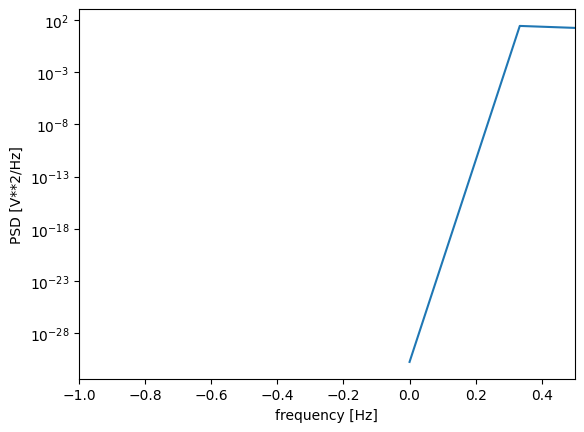

In [26]:
# exploration
filt = (df['trial'] == 5) & (df['condition'] == 1)
data = df.loc[filt, 'Fp1'].to_numpy()
import scipy.signal

# f contains the frequency components
# S is the PSD
(f, S) = scipy.signal.periodogram(data, 1024, scaling='density')
# (f, S)= scipy.signal.welch(data, 1024, nperseg=1024)
import matplotlib.pyplot as plt

plt.semilogy(f, S)
# plt.ylim([1e-2, 1e2])
plt.xlim([-1,0.5])
plt.xlabel('frequency [Hz]')
plt.ylabel('PSD [V**2/Hz]')
plt.show()

In [4]:
global_df.sort_values(by=['subject', 'condition'], inplace=True)
# global_df[global_df.select_dtypes(np.float64).columns] = global_df.select_dtypes(np.float64).astype(np.float32)
# global_df = global_df.astype({'subject': 'int8', 'condition': 'int8'})
global_df

,subject,condition,Fp1,AF7,AF3,F1,F3,F5,F7,FT7,...,CP2,P2,P4,P6,P8,P10,PO8,PO4,O2,time_ms
0,1,1,4.694972,2.070149,3.178188,5.471867,6.226539,4.160494,3.385864,4.273932,...,4.156895,4.918850,5.151279,4.092151,3.090429,1.245846,2.996408,4.748827,3.151972,-1500.0000
1,1,1,4.718298,2.019149,3.247921,5.635916,6.426880,4.441062,3.601036,4.230750,...,4.432032,5.139547,5.393025,4.412252,3.405242,1.611463,3.330815,4.949234,3.429169,-1499.0234
2,1,1,4.612990,2.060838,3.436402,5.843582,6.550092,4.404195,3.641622,4.240790,...,4.740057,5.442154,5.558568,4.609792,3.600952,1.846763,3.413057,5.238907,3.517107,-1498.0469
3,1,1,4.464822,2.209427,3.683950,5.829273,6.435086,4.202639,3.469223,4.102111,...,4.708069,5.435191,5.603686,4.586578,3.571783,1.725657,3.277763,5.178724,3.265150,-1497.0703
4,1,1,4.426163,2.327522,3.621894,5.694745,6.355737,4.028834,3.312064,3.989293,...,4.665796,5.451252,5.619635,4.620001,3.517113,1.637315,3.250003,5.160665,3.175901,-1496.0938
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359419,81,3,-1.767854,0.456810,-0.278523,-0.006992,0.003349,0.010220,-0.016654,0.753018,...,1.319372,0.050155,0.346991,-0.932256,0.128357,-0.154813,0.315715,0.474734,0.863147,1495.1172
359420,81,3,-1.551468,0.523857,-0.293416,-0.009024,0.032590,-0.014151,0.057629,0.778663,...,1.160952,-0.198152,0.060341,-1.191315,-0.136454,-0.338214,0.068372,0.371503,0.673871,1496.0938
359421,81,3,-1.429197,0.551953,-0.231390,-0.032266,0.149262,-0.018225,0.122059,0.847657,...,0.994058,-0.269558,-0.028525,-1.051387,0.062256,-0.330017,0.141756,0.410057,0.682258,1497.0703
359422,81,3,-1.397744,0.588607,-0.265430,-0.117681,0.184459,-0.048643,0.105742,0.897478,...,1.036175,-0.167436,0.020301,-0.842824,0.396513,-0.121367,0.434557,0.575310,0.912079,1498.0469


In [8]:
global_df.to_csv(os.path.join(r'C:\Users\meghnouh\PycharmProjects\Schizophrenia Detection\all_chans_ERP.csv'))

In [5]:
gg = global_df[(global_df['subject']==1) & (global_df['condition']==1)]['CPz']

In [7]:
print(gg[0])

4.926734


In [8]:
demographic[' group'].value_counts()

1    49
0    32
Name:  group, dtype: int64